# Credit Card Customer Segmentation - Complete Jupyter Notebook


##  STEP 1: IMPORT REQUIRED LIBRARIES



In [1]:
# Cell 1: Import Libraries and Load Data

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from scipy.stats import zscore
import scipy.cluster.hierarchy as sch
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
plt.style.use('default')
sns.set_palette("husl")
%matplotlib inline

print("✅ All required libraries imported successfully!")

✅ All required libraries imported successfully!


## STEP 2: COMPREHENSIVE DATA EXPLORATION (EDA)


In [2]:
# Cell 1: Load dataset

df = pd.read_csv('Customer Data.csv')
print(f"📊 Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")

📊 Dataset loaded: 8950 rows, 18 columns


### Comprehensive Exploratory Data Analysis


In [3]:
# Cell 2: Comprehensive Data Analysis

print("="*80)
print("PHASE 2: COMPREHENSIVE EXPLORATORY DATA ANALYSIS")
print("="*80)

# Basic dataset information
print("📋 DATASET OVERVIEW:")
print(f"• Number of customers: {df['CUST_ID'].nunique()}")
print(f"• Number of features: {len(df.columns)}")
print(f"• Data types:\n{df.dtypes.value_counts()}")

# Missing values analysis
print("\n🔍 MISSING VALUES ANALYSIS:")
missing_data = df.isnull().sum()
missing_percent = (missing_data / len(df)) * 100
missing_info = pd.DataFrame({
    'Missing Count': missing_data,
    'Missing Percentage': missing_percent
})
print(missing_info[missing_info['Missing Count'] > 0])

# Basic statistics
print("\n📈 BASIC STATISTICAL SUMMARY:")
print(df.describe())

PHASE 2: COMPREHENSIVE EXPLORATORY DATA ANALYSIS
📋 DATASET OVERVIEW:
• Number of customers: 8950
• Number of features: 18
• Data types:
float64    14
int64       3
object      1
Name: count, dtype: int64

🔍 MISSING VALUES ANALYSIS:
                  Missing Count  Missing Percentage
CREDIT_LIMIT                  1            0.011173
MINIMUM_PAYMENTS            313            3.497207

📈 BASIC STATISTICAL SUMMARY:
            BALANCE  BALANCE_FREQUENCY     PURCHASES  ONEOFF_PURCHASES  \
count   8950.000000        8950.000000   8950.000000       8950.000000   
mean    1564.474828           0.877271   1003.204834        592.437371   
std     2081.531879           0.236904   2136.634782       1659.887917   
min        0.000000           0.000000      0.000000          0.000000   
25%      128.281915           0.888889     39.635000          0.000000   
50%      873.385231           1.000000    361.280000         38.000000   
75%     2054.140036           1.000000   1110.130000        577.

📊 1. FEATURE DISTRIBUTIONS


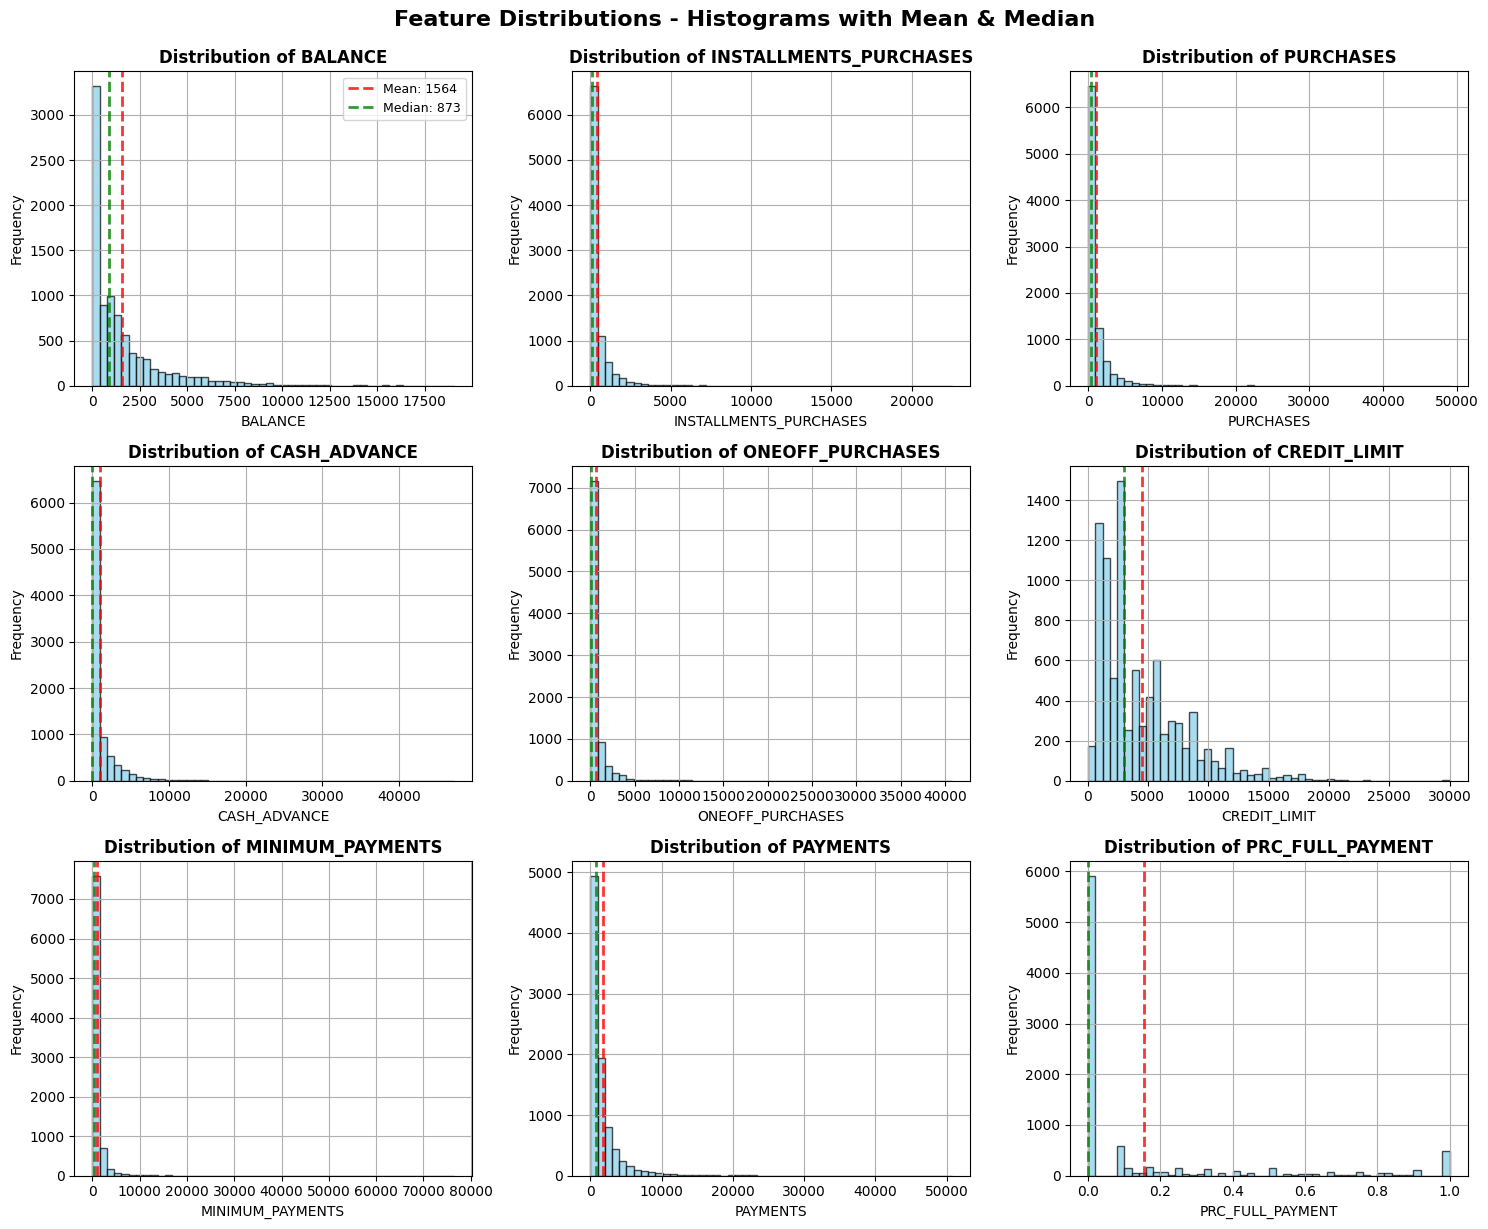

📈 2. CORRELATION ANALYSIS


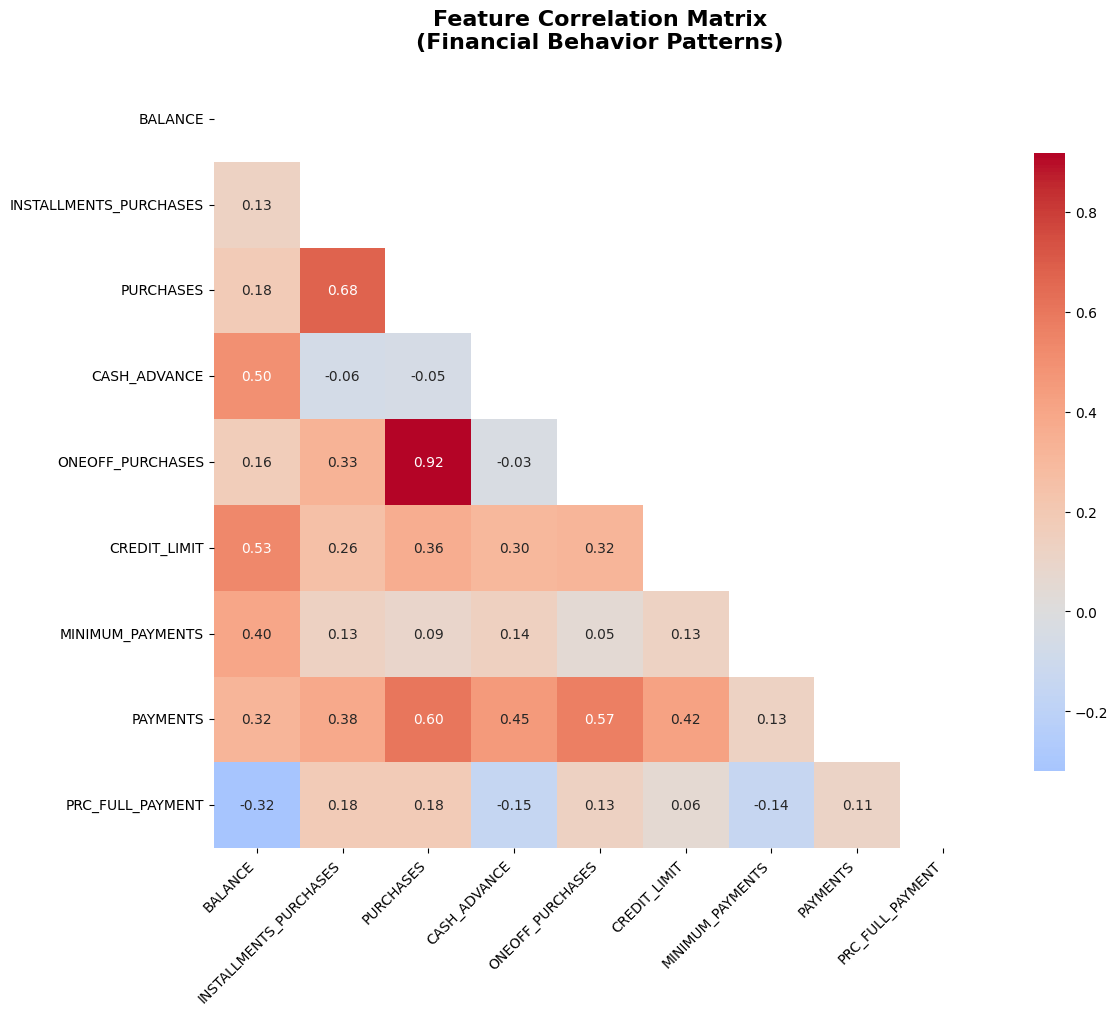


🔥 TOP POSITIVE CORRELATIONS:
PURCHASES               ONEOFF_PURCHASES          0.916845
ONEOFF_PURCHASES        PURCHASES                 0.916845
PURCHASES               INSTALLMENTS_PURCHASES    0.679896
INSTALLMENTS_PURCHASES  PURCHASES                 0.679896
PAYMENTS                PURCHASES                 0.603264
dtype: float64

🧊 TOP NEGATIVE CORRELATIONS:
MINIMUM_PAYMENTS  PRC_FULL_PAYMENT   -0.140379
PRC_FULL_PAYMENT  CASH_ADVANCE       -0.152935
CASH_ADVANCE      PRC_FULL_PAYMENT   -0.152935
BALANCE           PRC_FULL_PAYMENT   -0.318959
PRC_FULL_PAYMENT  BALANCE            -0.318959
dtype: float64


In [4]:
# Select key numerical features for EDA - matching the image
numerical_features = ['BALANCE', 'INSTALLMENTS_PURCHASES', 'PURCHASES', 'CASH_ADVANCE', 
                     'ONEOFF_PURCHASES', 'CREDIT_LIMIT', 'MINIMUM_PAYMENTS', 'PAYMENTS',
                     'PRC_FULL_PAYMENT']  # or 'PRO_FULL_PAYMENT' depending on your actual data

# 3. Distribution Analysis
print("📊 1. FEATURE DISTRIBUTIONS")
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.ravel()

for i, feature in enumerate(numerical_features[:9]):
    if feature in df.columns:
        # Histogram with KDE
        df[feature].hist(bins=50, ax=axes[i], alpha=0.7, color='skyblue', edgecolor='black')
        axes[i].set_title(f'Distribution of {feature}', fontsize=12, fontweight='bold')
        axes[i].set_xlabel(feature)
        axes[i].set_ylabel('Frequency')
        
        # Add statistics
        mean_val = df[feature].mean()
        median_val = df[feature].median()
        axes[i].axvline(mean_val, color='red', linestyle='--', alpha=0.8, linewidth=2, 
                       label=f'Mean: {mean_val:.0f}')
        axes[i].axvline(median_val, color='green', linestyle='--', alpha=0.8, linewidth=2, 
                       label=f'Median: {median_val:.0f}')
        
        # Add legend to first subplot only to avoid clutter
        if i == 0:
            axes[i].legend(fontsize=9, loc='upper right')

# Remove empty subplots if any
for i in range(len(numerical_features), 9):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.suptitle('Feature Distributions - Histograms with Mean & Median', fontsize=16, fontweight='bold', y=1.02)
plt.show()

# 4. Correlation Analysis
print("📈 2. CORRELATION ANALYSIS")
# Select features for correlation matrix
corr_features = [f for f in numerical_features if f in df.columns]
if len(corr_features) > 1:
    correlation_matrix = df[corr_features].corr()
    
    plt.figure(figsize=(12, 10))
    mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
    sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap='coolwarm', center=0,
                square=True, fmt='.2f', cbar_kws={"shrink": .8}, annot_kws={'size': 10})
    plt.title('Feature Correlation Matrix\n(Financial Behavior Patterns)', 
              fontsize=16, fontweight='bold', pad=20)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()
    
    # Display top correlations
    print("\n🔥 TOP POSITIVE CORRELATIONS:")
    corr_pairs = correlation_matrix.unstack()
    sorted_corr = corr_pairs.sort_values(ascending=False)
    # Remove self-correlations and duplicates
    sorted_corr = sorted_corr[sorted_corr != 1.0]
    sorted_corr = sorted_corr[~sorted_corr.index.duplicated(keep='first')]
    print(sorted_corr.head(5))
    
    print("\n🧊 TOP NEGATIVE CORRELATIONS:")
    print(sorted_corr.tail(5))

### Outlier Detection and Visualization


🔍 OUTLIER DETECTION USING IQR METHOD
📊 OUTLIER ANALYSIS RESULTS (Financial Data - Upper Bound Only):
Feature                  Outliers    Percentage     Upper Bound
------------------------------------------------------------
BALANCE                  695         7.77%          4942.93
PURCHASES                808         9.03%          2715.87
ONEOFF_PURCHASES         1013        11.32%         1443.51
INSTALLMENTS_PURCHASES   867         9.69%          1171.59
CASH_ADVANCE             1030        11.51%         2784.55
CREDIT_LIMIT             248         2.77%          13850.00
PAYMENTS                 808         9.03%          4177.92
MINIMUM_PAYMENTS         841         9.40%          1810.03

📈 SUMMARY:
Total upper-bound outliers detected: 6310
Average outlier percentage: 8.81%
Feature with most outliers: CASH_ADVANCE (11.51%)

📋 DATA RANGES FOR CONTEXT:
BALANCE                  Range: 0.00 to 19043.14
PURCHASES                Range: 0.00 to 49039.57
ONEOFF_PURCHASES         Rang

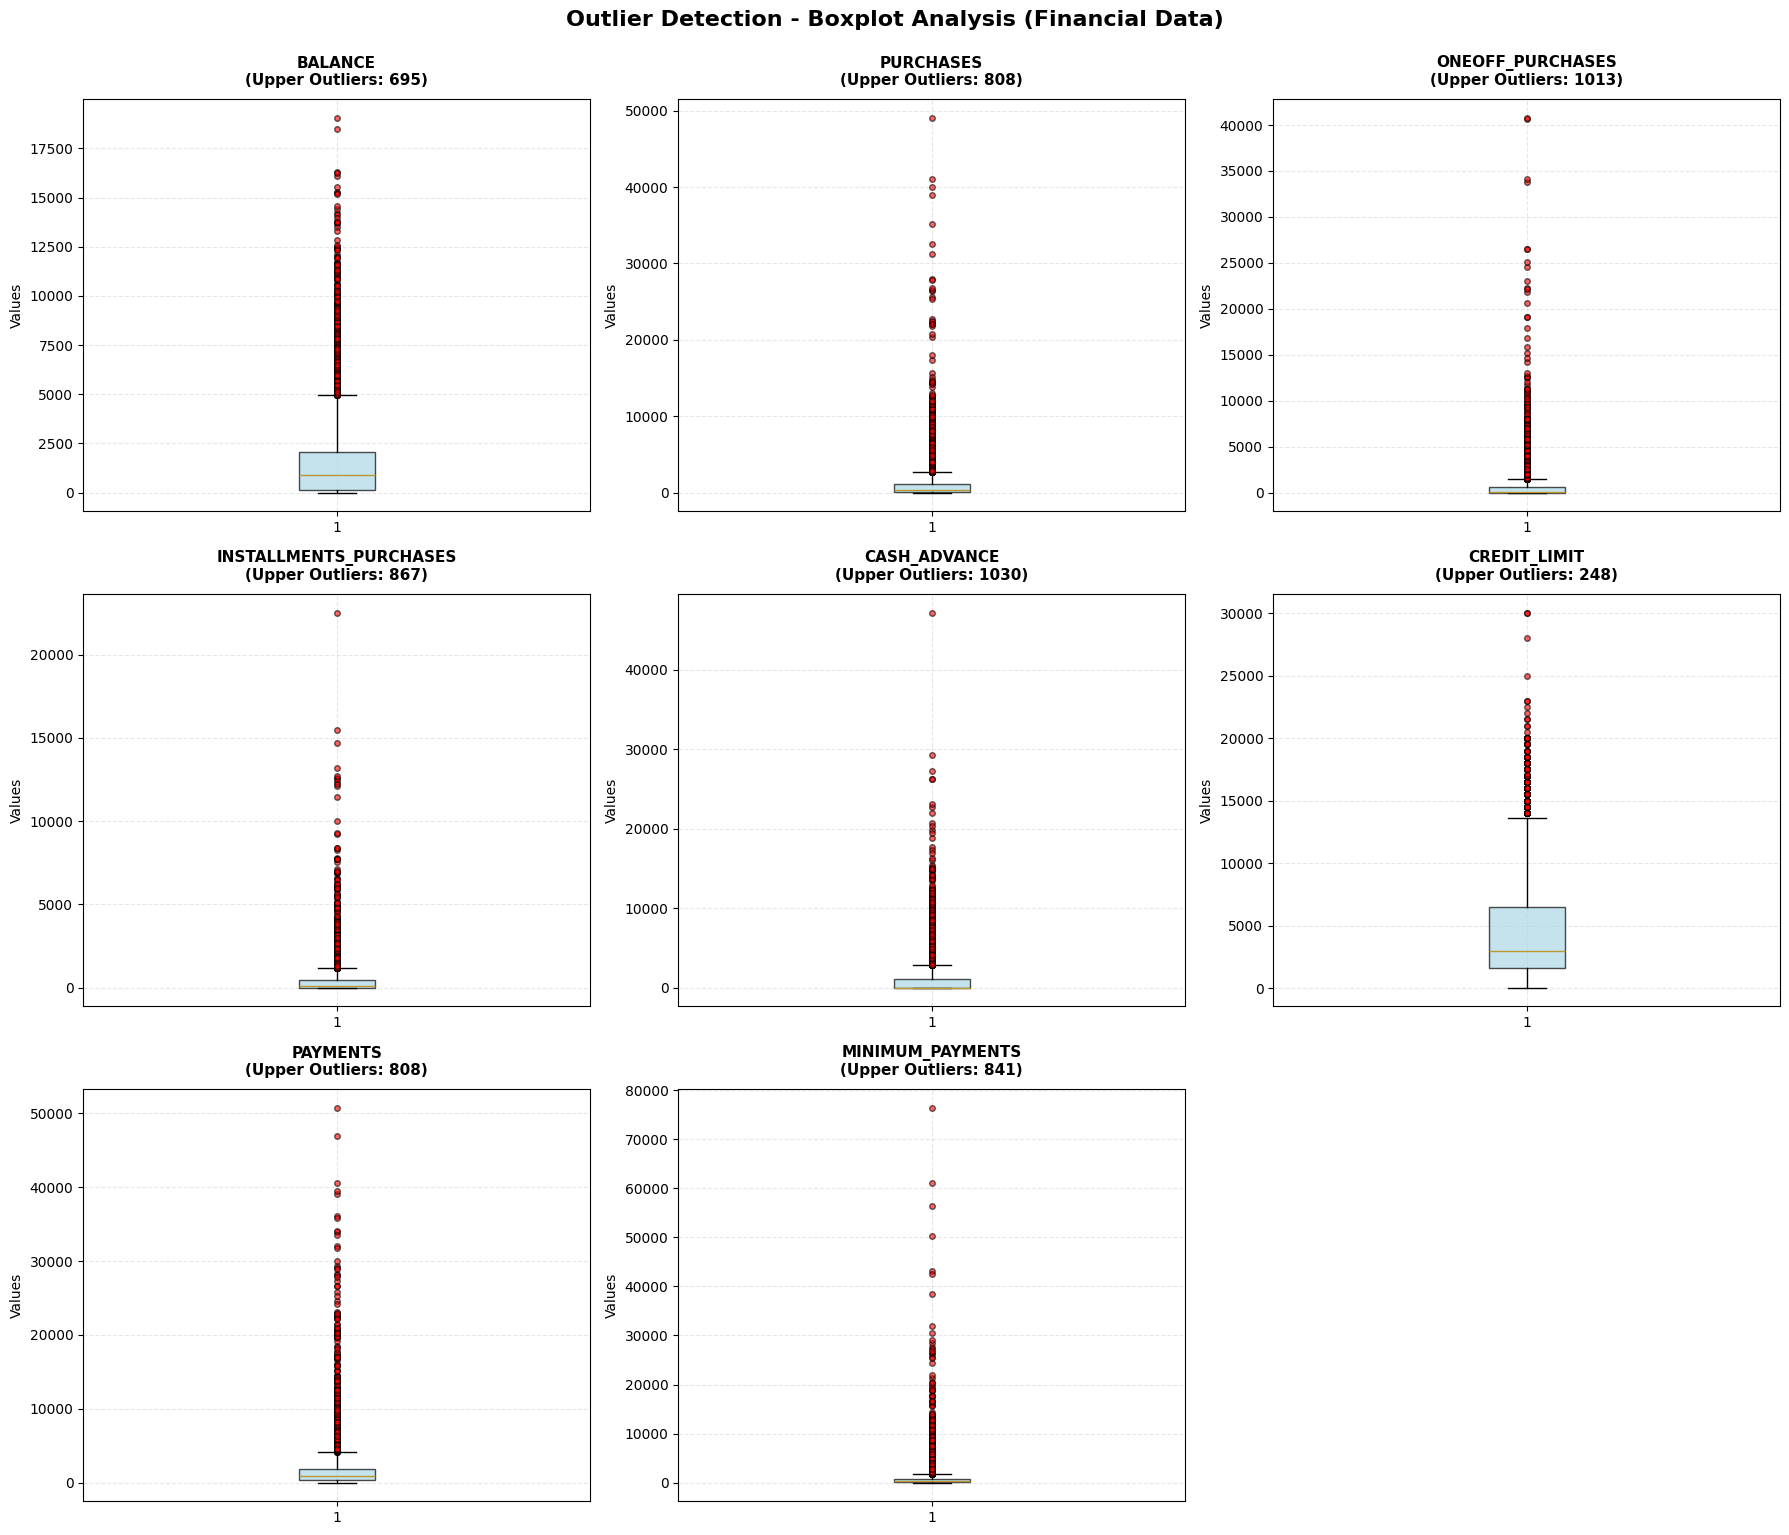

In [5]:
# Cell 5: Enhanced Outlier Detection and Analysis

print("="*80)
print("🔍 OUTLIER DETECTION USING IQR METHOD")
print("="*80)

def detect_outliers_iqr_financial(data, feature):
    """Detect outliers using Interquartile Range method for financial data"""
    Q1 = data[feature].quantile(0.25)
    Q3 = data[feature].quantile(0.75)
    IQR = Q3 - Q1
    
    # For financial data, we typically only care about upper-bound outliers
    # since lower bound should be 0 or positive
    lower_bound = 0  # Financial data can't be negative
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = data[data[feature] > upper_bound]  # Only upper outliers
    outlier_percentage = (len(outliers) / len(data)) * 100
    
    return len(outliers), outlier_percentage, lower_bound, upper_bound

def detect_outliers_iqr_standard(data, feature):
    """Standard IQR method for reference"""
    Q1 = data[feature].quantile(0.25)
    Q3 = data[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = data[(data[feature] < lower_bound) | (data[feature] > upper_bound)]
    outlier_percentage = (len(outliers) / len(data)) * 100
    
    return len(outliers), outlier_percentage, lower_bound, upper_bound

# Select numerical features for outlier analysis
numerical_features = ['BALANCE', 'PURCHASES', 'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES',
                     'CASH_ADVANCE', 'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS']

print("📊 OUTLIER ANALYSIS RESULTS (Financial Data - Upper Bound Only):")
print("Feature".ljust(25) + "Outliers".ljust(12) + "Percentage".ljust(15) + "Upper Bound")
print("-" * 60)

# Calculate and display outlier statistics
outlier_summary = []
for feature in numerical_features:
    if feature in df.columns:
        n_outliers, percentage, lower, upper = detect_outliers_iqr_financial(df, feature)
        outlier_summary.append({
            'feature': feature,
            'outliers': n_outliers,
            'percentage': percentage,
            'upper_bound': upper
        })
        print(f"{feature.ljust(25)}{str(n_outliers).ljust(12)}{f'{percentage:.2f}%'.ljust(15)}{f'{upper:.2f}'}")

# Display summary statistics
print(f"\n📈 SUMMARY:")
total_outliers = sum([x['outliers'] for x in outlier_summary])
avg_percentage = sum([x['percentage'] for x in outlier_summary]) / len(outlier_summary)
print(f"Total upper-bound outliers detected: {total_outliers}")
print(f"Average outlier percentage: {avg_percentage:.2f}%")

if outlier_summary:
    most_outliers = max(outlier_summary, key=lambda x: x['percentage'])
    print(f"Feature with most outliers: {most_outliers['feature']} ({most_outliers['percentage']:.2f}%)")

# Additional: Show data ranges for context
print(f"\n📋 DATA RANGES FOR CONTEXT:")
for feature in numerical_features:
    if feature in df.columns:
        min_val = df[feature].min()
        max_val = df[feature].max()
        print(f"{feature.ljust(25)}Range: {min_val:.2f} to {max_val:.2f}")

# 3. Outlier Detection using Boxplots
print("\n📦 3. OUTLIER DETECTION - BOXPLOTS")
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.ravel()

available_features = [f for f in numerical_features if f in df.columns]

for i, feature in enumerate(available_features[:9]):
    # Create boxplot
    boxplot = axes[i].boxplot(df[feature].dropna(), patch_artist=True, 
                             boxprops=dict(facecolor='lightblue', alpha=0.7),
                             flierprops=dict(marker='o', markerfacecolor='red', 
                                           markersize=4, alpha=0.6))
    
    # Use financial outlier detection for counts
    n_outliers, _, _, _ = detect_outliers_iqr_financial(df, feature)
    
    axes[i].set_title(f'{feature}\n(Upper Outliers: {n_outliers})', 
                     fontsize=11, fontweight='bold', pad=10)
    axes[i].set_ylabel('Values')
    
    # Add grid for better readability
    axes[i].grid(True, alpha=0.3, linestyle='--')

# Remove empty subplots
for i in range(len(available_features[:9]), 9):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.suptitle('Outlier Detection - Boxplot Analysis (Financial Data)', fontsize=16, fontweight='bold', y=1.02)
plt.show()

##  STEP 3: DATA PREPROCESSING - HANDLE MISSING VALUES & OUTLIERS


### Handel Missing Value & Outliers


In [6]:
# =============================================================================
# CELL 1: DATA PREPROCESSING - HANDLE MISSING VALUES & OUTLIERS
# =============================================================================
print("="*80)
print("🛠️ PHASE 2: DATA PREPROCESSING")
print("="*80)

# Create a clean copy for processing
df_clean = df.copy()

print("🔄 1. HANDLING MISSING VALUES")
# Fill missing values with median
for column in df_clean.columns:
    if df_clean[column].isnull().sum() > 0 and df_clean[column].dtype in ['float64', 'int64']:
        median_val = df_clean[column].median()
        df_clean[column] = df_clean[column].fillna(median_val)
        print(f"   ✅ {column}: Filled {df_clean[column].isnull().sum()} missing values with median {median_val:.2f}")

print(f"   📊 Missing values after treatment: {df_clean.isnull().sum().sum()}")

print("\n🔍 2. OUTLIER DETECTION USING IQR METHOD")

def detect_outliers_iqr_financial(data, feature):
    """Detect outliers using Interquartile Range method for financial data"""
    Q1 = data[feature].quantile(0.25)
    Q3 = data[feature].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = 0  # Financial data can't be negative
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = data[data[feature] > upper_bound]  # Only upper outliers
    outlier_percentage = (len(outliers) / len(data)) * 100
    
    return len(outliers), outlier_percentage, lower_bound, upper_bound

# Detect outliers in numerical features
numerical_features = ['BALANCE', 'PURCHASES', 'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES',
                     'CASH_ADVANCE', 'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS']

outlier_info = {}

print("   📊 OUTLIER ANALYSIS RESULTS (Upper Bound Only):")
print("   " + "-" * 70)
print("   Feature".ljust(25) + "Outliers".ljust(12) + "Percentage".ljust(15) + "Upper Bound")
print("   " + "-" * 70)

# ✅ SINGLE LOOP FOR OUTLIER DETECTION
for feature in numerical_features:
    if feature in df.columns:  # Use original df for consistency with EDA
        n_outliers, percentage, lower, upper = detect_outliers_iqr_financial(df, feature)
        outlier_info[feature] = {
            'count': n_outliers,
            'percentage': percentage, 
            'upper_bound': upper
        }
        print(f"   {feature:25} {n_outliers:<10} {percentage:<7.1f}% {upper:>12.2f}")

print("\n🛠️ 3. HANDLING OUTLIERS USING FINANCIAL CAPPING METHOD")
df_processed = df_clean.copy()  # Use cleaned data (with missing values filled)

for feature in numerical_features:
    if feature in outlier_info:
        upper_bound = outlier_info[feature]['upper_bound']
        
        # Cap only upper outliers, keep lower bound at 0
        before_count = outlier_info[feature]['count']
        df_processed[feature] = np.clip(df_processed[feature], 0, upper_bound)
        
        # Verify capping worked
        after_count, _, _, _ = detect_outliers_iqr_financial(df_processed, feature)
        
        print(f"   ✅ {feature:25} | Capped {before_count - after_count} upper outliers (0 to {upper_bound:.2f})")

print(f"\n📊 Dataset shape after preprocessing: {df_processed.shape}")

# Verify no negative values remain
print(f"\n🔍 DATA VALIDATION:")
negative_counts = (df_processed[numerical_features] < 0).sum().sum()
print(f"   Negative values after processing: {negative_counts}")
print(f"   Data ranges after capping:")
for feature in numerical_features:
    if feature in df_processed.columns:
        min_val = df_processed[feature].min()
        max_val = df_processed[feature].max()
        print(f"   {feature:25} Range: {min_val:8.2f} to {max_val:8.2f}")

# ✅ CONSISTENCY CHECK WITH EDA
print(f"\n🎯 CONSISTENCY CHECK WITH EDA:")
eda_results = {
    'BALANCE': 695, 'PURCHASES': 808, 'ONEOFF_PURCHASES': 1013,
    'INSTALLMENTS_PURCHASES': 867, 'CASH_ADVANCE': 1030,
    'CREDIT_LIMIT': 248, 'PAYMENTS': 808, 'MINIMUM_PAYMENTS': 841
}

print("   Feature".ljust(25) + "EDA".ljust(10) + "Preprocessing".ljust(15) + "Status")
print("   " + "-" * 55)
all_match = True
for feature in numerical_features:
    if feature in outlier_info and feature in eda_results:
        eda_count = eda_results[feature]
        proc_count = outlier_info[feature]['count']
        status = "✅ MATCH" if eda_count == proc_count else " MISMATCH"
        if eda_count != proc_count:
            all_match = False
        print(f"   {feature:25} {eda_count:<9} {proc_count:<14} {status}")

if all_match:
    print(f"\n🎉 EXCELLENT! All outlier counts match with EDA results!")
else:
    print(f"\n⚠️  Warning: Some outlier counts don't match with EDA")

🛠️ PHASE 2: DATA PREPROCESSING
🔄 1. HANDLING MISSING VALUES
   ✅ CREDIT_LIMIT: Filled 0 missing values with median 3000.00
   ✅ MINIMUM_PAYMENTS: Filled 0 missing values with median 312.34
   📊 Missing values after treatment: 0

🔍 2. OUTLIER DETECTION USING IQR METHOD
   📊 OUTLIER ANALYSIS RESULTS (Upper Bound Only):
   ----------------------------------------------------------------------
   Feature               Outliers    Percentage     Upper Bound
   ----------------------------------------------------------------------
   BALANCE                   695        7.8    %      4942.93
   PURCHASES                 808        9.0    %      2715.87
   ONEOFF_PURCHASES          1013       11.3   %      1443.51
   INSTALLMENTS_PURCHASES    867        9.7    %      1171.59
   CASH_ADVANCE              1030       11.5   %      2784.55
   CREDIT_LIMIT              248        2.8    %     13850.00
   PAYMENTS                  808        9.0    %      4177.92
   MINIMUM_PAYMENTS          841   

## STEP 4: FEATURE ENGINEERING


In [18]:
# =============================================================================
# CELL 1: FEATURE ENGINEERING
# =============================================================================
print("🔧 3. FEATURE ENGINEERING")

# Create meaningful business features
df_engineered = df_processed.copy()

# 1. Credit Utilization Features
print("   💳 Creating credit utilization features...")
if 'BALANCE' in df_engineered.columns and 'CREDIT_LIMIT' in df_engineered.columns:
    df_engineered['CREDIT_UTILIZATION_RATIO'] = df_engineered['BALANCE'] / df_engineered['CREDIT_LIMIT'].replace(0, np.nan)
if 'CASH_ADVANCE' in df_engineered.columns and 'CREDIT_LIMIT' in df_engineered.columns:
    df_engineered['CASH_ADVANCE_UTILIZATION'] = df_engineered['CASH_ADVANCE'] / df_engineered['CREDIT_LIMIT'].replace(0, np.nan)

# 2. Payment Behavior Features
print("   💰 Creating payment behavior features...")
if 'PAYMENTS' in df_engineered.columns and 'BALANCE' in df_engineered.columns:
    df_engineered['PAYMENT_TO_BALANCE_RATIO'] = df_engineered['PAYMENTS'] / df_engineered['BALANCE'].replace(0, np.nan)
if 'MINIMUM_PAYMENTS' in df_engineered.columns and 'BALANCE' in df_engineered.columns:
    df_engineered['MIN_PAYMENT_RATIO'] = df_engineered['MINIMUM_PAYMENTS'] / df_engineered['BALANCE'].replace(0, np.nan)

# 3. Spending Pattern Features
print("   🛍️ Creating spending pattern features...")
if 'PURCHASES' in df_engineered.columns and 'PURCHASES_TRX' in df_engineered.columns:
    df_engineered['AVG_PURCHASE_VALUE'] = df_engineered['PURCHASES'] / df_engineered['PURCHASES_TRX'].replace(0, np.nan)
if 'ONEOFF_PURCHASES' in df_engineered.columns and 'PURCHASES' in df_engineered.columns:
    df_engineered['ONEOFF_PURCHASE_RATIO'] = df_engineered['ONEOFF_PURCHASES'] / df_engineered['PURCHASES'].replace(0, np.nan)
if 'INSTALLMENTS_PURCHASES' in df_engineered.columns and 'PURCHASES' in df_engineered.columns:
    df_engineered['INSTALLMENT_PURCHASE_RATIO'] = df_engineered['INSTALLMENTS_PURCHASES'] / df_engineered['PURCHASES'].replace(0, np.nan)

# 4. Behavioral Features
print("   📊 Creating behavioral features...")
if 'PURCHASES_FREQUENCY' in df_engineered.columns and 'CASH_ADVANCE_FREQUENCY' in df_engineered.columns:
    df_engineered['TOTAL_ACTIVITY_SCORE'] = (df_engineered['PURCHASES_FREQUENCY'] + df_engineered['CASH_ADVANCE_FREQUENCY']) / 2

# Handle infinite values in engineered features
engineered_features = [col for col in df_engineered.columns if col not in df_processed.columns]
print(f"\n   🔧 Handling infinite values in {len(engineered_features)} engineered features...")

for feature in engineered_features:
    df_engineered[feature] = df_engineered[feature].replace([np.inf, -np.inf], np.nan)
    df_engineered[feature] = df_engineered[feature].fillna(df_engineered[feature].median())

print(f"   ✅ Created {len(engineered_features)} new business features")
# Ensure processed dataframe contains the engineered features for downstream cells
df_processed = df_engineered.copy()
print("   ✅ Updated df_processed with engineered features")
print(f"   📊 Final dataset shape: {df_engineered.shape}")

🔧 3. FEATURE ENGINEERING
   💳 Creating credit utilization features...
   💰 Creating payment behavior features...
   🛍️ Creating spending pattern features...
   📊 Creating behavioral features...

   🔧 Handling infinite values in 2 engineered features...
   ✅ Created 2 new business features
   ✅ Updated df_processed with engineered features
   📊 Final dataset shape: (8950, 25)


### Correlation Analysis After Feature Engineering


## STEP 5: FEATURE SELECTION AND SCALING


In [19]:
# =============================================================================
# CELL 1: FEATURE SELECTION AND SCALING
# =============================================================================
print("🎯 5. FEATURE SELECTION AND SCALING")

# Select features for clustering analysis
clustering_features = []

# Original financial features
original_features = ['BALANCE', 'PURCHASES', 'CASH_ADVANCE', 'CREDIT_LIMIT', 'PAYMENTS',
                    'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT']
clustering_features.extend([f for f in original_features if f in df_engineered.columns])

# Behavioral frequency features
frequency_features = ['BALANCE_FREQUENCY', 'PURCHASES_FREQUENCY', 'CASH_ADVANCE_FREQUENCY']
clustering_features.extend([f for f in frequency_features if f in df_engineered.columns])

# Engineered features
engineered_clustering_features = ['CREDIT_UTILIZATION_RATIO', 'CASH_ADVANCE_UTILIZATION',
                                 'AVG_PURCHASE_VALUE', 'TOTAL_ACTIVITY_SCORE']
clustering_features.extend([f for f in engineered_clustering_features if f in df_engineered.columns])

print(f"   📋 Selected {len(clustering_features)} features for clustering:")
for i, feature in enumerate(clustering_features, 1):
    print(f"      {i:2d}. {feature}")

# Prepare data for clustering
print("\n   🔄 Preparing data for clustering...")
X = df_engineered[clustering_features].fillna(df_engineered[clustering_features].median())

# Check for any infinite values
if np.any(np.isinf(X.values)):
    print("   ⚠️  Infinite values found in data. Cleaning...")
    X = X.replace([np.inf, -np.inf], np.nan)
    X = X.fillna(X.median())

print(f"   📊 Feature matrix shape: {X.shape}")

# Scale features using RobustScaler (better for data with outliers)
print("   ⚖️  Scaling features using RobustScaler...")
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

# Verify no infinite or NaN values in scaled data
if np.any(np.isnan(X_scaled)) or np.any(np.isinf(X_scaled)):
    print("   🧹 Cleaning scaled data...")
    X_scaled = np.nan_to_num(X_scaled, nan=0.0, posinf=0.0, neginf=0.0)

print(f"   ✅ Scaled data shape: {X_scaled.shape}")

🎯 5. FEATURE SELECTION AND SCALING
   📋 Selected 14 features for clustering:
       1. BALANCE
       2. PURCHASES
       3. CASH_ADVANCE
       4. CREDIT_LIMIT
       5. PAYMENTS
       6. MINIMUM_PAYMENTS
       7. PRC_FULL_PAYMENT
       8. BALANCE_FREQUENCY
       9. PURCHASES_FREQUENCY
      10. CASH_ADVANCE_FREQUENCY
      11. CREDIT_UTILIZATION_RATIO
      12. CASH_ADVANCE_UTILIZATION
      13. AVG_PURCHASE_VALUE
      14. TOTAL_ACTIVITY_SCORE

   🔄 Preparing data for clustering...
   📊 Feature matrix shape: (8950, 14)
   ⚖️  Scaling features using RobustScaler...
   ✅ Scaled data shape: (8950, 14)


## STEP 6: DIMENSIONALITY REDUCTION - PCA



### Principal Component Analysis (PCA)


📉 PHASE 3: DIMENSIONALITY REDUCTION - PCA


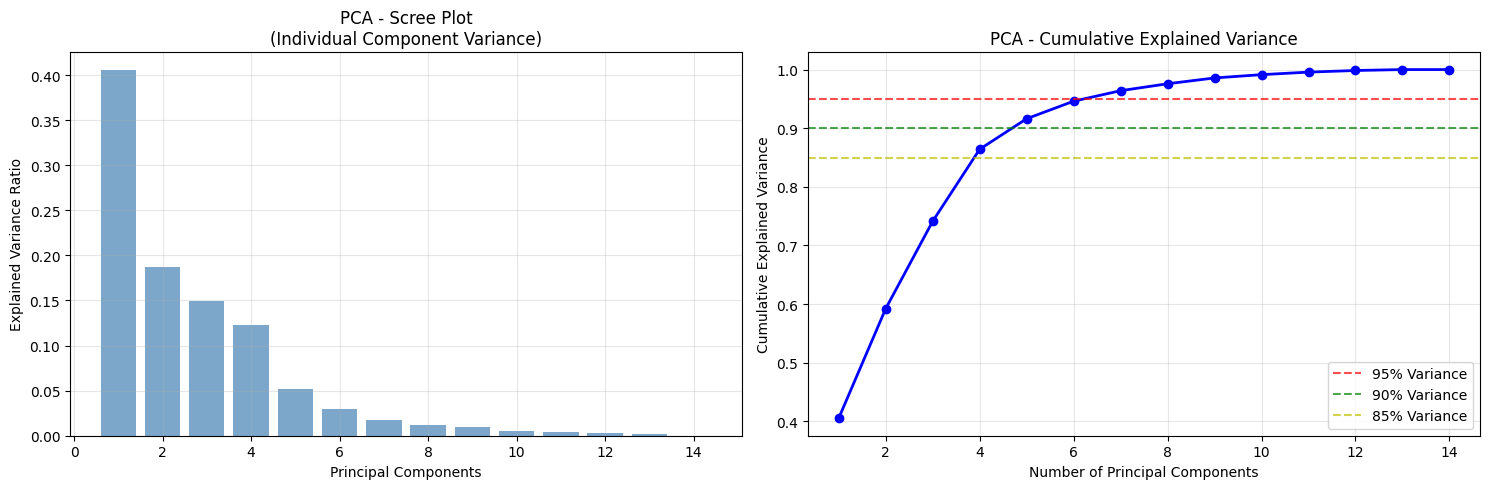

🔍 OPTIMAL COMPONENTS ANALYSIS:
   • Components needed for 95% variance: 7
   • Components needed for 90% variance: 5
   • Components needed for 85% variance: 4

📊 PCA 2D PROJECTION VISUALIZATION



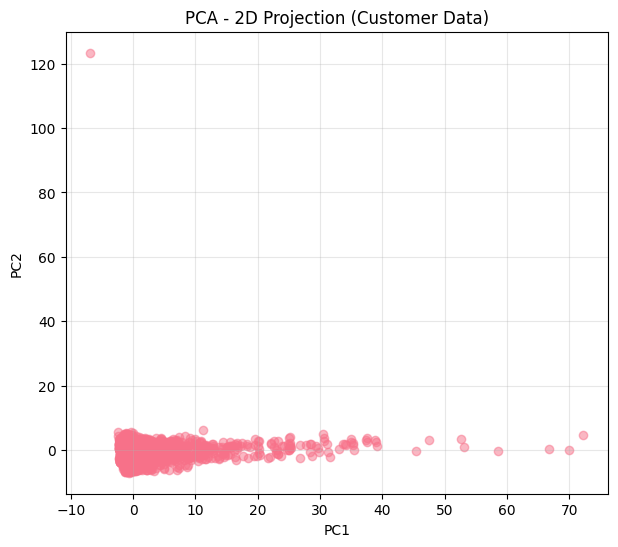

In [20]:
# =============================================================================
# CELL 1: DIMENSIONALITY REDUCTION - PCA
# =============================================================================
print("="*80)
print("📉 PHASE 3: DIMENSIONALITY REDUCTION - PCA")
print("="*80)

try:
    # Apply PCA
    pca = PCA()
    X_pca = pca.fit_transform(X_scaled)

    # Calculate explained variance
    explained_variance = np.cumsum(pca.explained_variance_ratio_)

    # Visualize PCA results
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Scree plot
    ax1.bar(
        range(1, len(pca.explained_variance_ratio_) + 1),
        pca.explained_variance_ratio_,
        alpha=0.7,
        color='steelblue'
    )
    ax1.set_xlabel('Principal Components')
    ax1.set_ylabel('Explained Variance Ratio')
    ax1.set_title('PCA - Scree Plot\n(Individual Component Variance)')
    ax1.grid(True, alpha=0.3)

    # Cumulative explained variance
    ax2.plot(
        range(1, len(explained_variance) + 1),
        explained_variance,
        'bo-', linewidth=2, markersize=6
    )
    ax2.axhline(y=0.95, color='r', linestyle='--', label='95% Variance', alpha=0.7)
    ax2.axhline(y=0.90, color='g', linestyle='--', label='90% Variance', alpha=0.7)
    ax2.axhline(y=0.85, color='y', linestyle='--', label='85% Variance', alpha=0.7)
    ax2.set_xlabel('Number of Principal Components')
    ax2.set_ylabel('Cumulative Explained Variance')
    ax2.set_title('PCA - Cumulative Explained Variance')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Determine optimal number of components
    n_components_95 = np.where(explained_variance >= 0.95)[0][0] + 1 \
                        if len(np.where(explained_variance >= 0.95)[0]) > 0 \
                        else len(explained_variance)

    n_components_90 = np.where(explained_variance >= 0.90)[0][0] + 1 \
                        if len(np.where(explained_variance >= 0.90)[0]) > 0 \
                        else len(explained_variance)

    print("🔍 OPTIMAL COMPONENTS ANALYSIS:")
    print(f"   • Components needed for 95% variance: {n_components_95}")
    print(f"   • Components needed for 90% variance: {n_components_90}")
    print(f"   • Components needed for 85% variance: {np.where(explained_variance >= 0.85)[0][0] + 1}")

    # -------------------------------------------------------------------------
    # PCA 2D Visualization
    # -------------------------------------------------------------------------
    print("\n📊 PCA 2D PROJECTION VISUALIZATION\n")

    pca_2d = PCA(n_components=2)
    X_pca_2d = pca_2d.fit_transform(X_scaled)

    plt.figure(figsize=(7, 6))
    plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], alpha=0.5)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title("PCA - 2D Projection (Customer Data)")
    plt.grid(True, alpha=0.3)
    plt.show()

except Exception as e:
    print(f"❌ Error in PCA: {e}")


## STEP 7: DIMENSIONALITY REDUCTION - t-SNE



🎨 DIMENSIONALITY REDUCTION: t-SNE VISUALIZATION
   🔄 Applying t-SNE with perplexity: 30


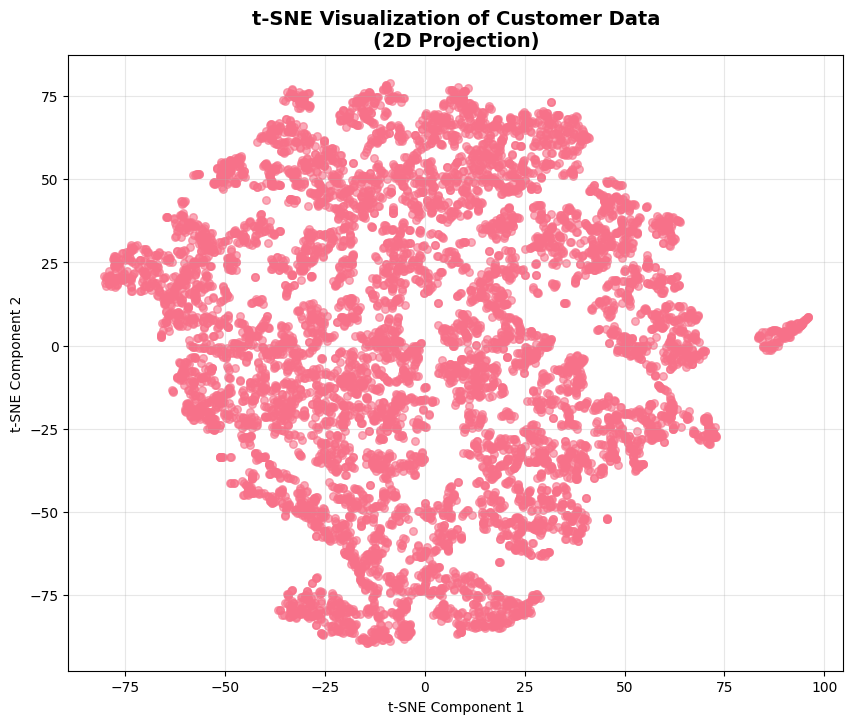

✅ t-SNE visualization completed successfully!


In [15]:
# =============================================================================
# CELL 1: DIMENSIONALITY REDUCTION - t-SNE
# =============================================================================

print("🎨 DIMENSIONALITY REDUCTION: t-SNE VISUALIZATION")


    # Apply t-SNE for non-linear dimensionality reduction
n_samples = X_scaled.shape[0]
perplexity_value = min(30, n_samples - 1)  # Ensure perplexity is valid

# Apply t-SNE for non-linear dimensionality reduction
print(f"   🔄 Applying t-SNE with perplexity: {perplexity_value}")
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
X_tsne = tsne.fit_transform(X_scaled)

# Visualize t-SNE results
plt.figure(figsize=(10, 8))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], alpha=0.6, s=30)
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.title('t-SNE Visualization of Customer Data\n(2D Projection)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.show()

print("✅ t-SNE visualization completed successfully!")

## STEP 8: PERFORMANCE EVALUATION


### Optimal Cluster Determination


In [16]:
# Cell 1: Determine Optimal Number of Clusters

print("🔢 DETERMINING OPTIMAL NUMBER OF CLUSTERS")

# Evaluate different numbers of clusters
k_range = range(2, 8)
results = []

print("Evaluating K-Means for different cluster numbers:")
print("K".ljust(5) + "WCSS".ljust(15) + "Silhouette".ljust(15) + "Calinski".ljust(15) + "Davies".ljust(15))
print("-" * 65)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_scaled)
    
    # Calculate multiple evaluation metrics
    wcss = kmeans.inertia_
    silhouette = silhouette_score(X_scaled, cluster_labels)
    calinski = calinski_harabasz_score(X_scaled, cluster_labels)
    davies = davies_bouldin_score(X_scaled, cluster_labels)
    
    results.append({
        'k': k,
        'wcss': wcss,
        'silhouette': silhouette,
        'calinski': calinski,
        'davies': davies
    })
    
    print(f"{k:<5} {wcss:<14.2f} {silhouette:<14.3f} {calinski:<14.2f} {davies:<14.3f}")

# Convert to DataFrame for easier analysis
results_df = pd.DataFrame(results)

# Find optimal k based on silhouette score (higher is better)
optimal_k = results_df.loc[results_df['silhouette'].idxmax(), 'k']
print(f"\n🎯 Optimal number of clusters: {optimal_k} (based on highest silhouette score)")

🔢 DETERMINING OPTIMAL NUMBER OF CLUSTERS
Evaluating K-Means for different cluster numbers:
K    WCSS           Silhouette     Calinski       Davies         
-----------------------------------------------------------------
2     216894.28      0.772          3119.82        0.550         
3     177693.63      0.330          2890.71        1.264         
4     144825.34      0.348          3041.02        0.828         
5     114324.50      0.380          3485.54        0.761         
6     97543.82       0.388          3575.50        0.752         
7     83764.70       0.280          3714.51        0.941         

🎯 Optimal number of clusters: 2 (based on highest silhouette score)


### Comprehensive Metrics Evaluation


📊 VISUALIZING CLUSTER EVALUATION METRICS


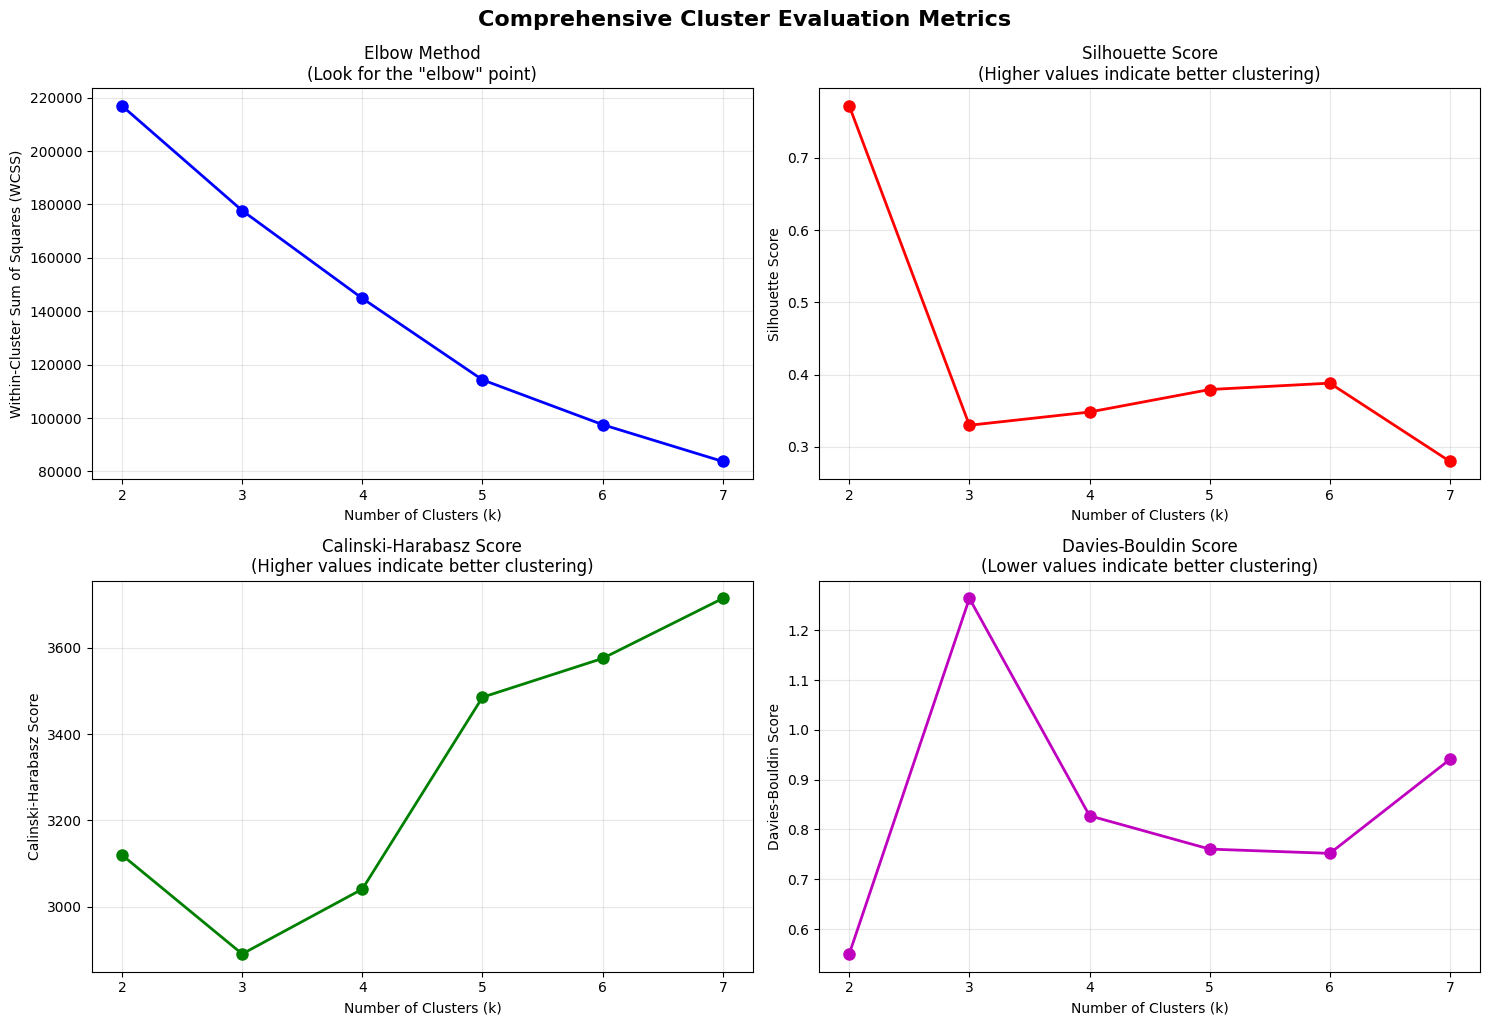

In [17]:
# Cell 2: Visualize Cluster Evaluation Metrics

print("📊 VISUALIZING CLUSTER EVALUATION METRICS")

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))

# Elbow curve (WCSS)
ax1.plot(results_df['k'], results_df['wcss'], 'bo-', linewidth=2, markersize=8)
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Within-Cluster Sum of Squares (WCSS)')
ax1.set_title('Elbow Method\n(Look for the "elbow" point)')
ax1.grid(True, alpha=0.3)

# Silhouette scores
ax2.plot(results_df['k'], results_df['silhouette'], 'ro-', linewidth=2, markersize=8)
ax2.set_xlabel('Number of Clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score\n(Higher values indicate better clustering)')
ax2.grid(True, alpha=0.3)

# Calinski-Harabasz scores
ax3.plot(results_df['k'], results_df['calinski'], 'go-', linewidth=2, markersize=8)
ax3.set_xlabel('Number of Clusters (k)')
ax3.set_ylabel('Calinski-Harabasz Score')
ax3.set_title('Calinski-Harabasz Score\n(Higher values indicate better clustering)')
ax3.grid(True, alpha=0.3)

# Davies-Bouldin scores
ax4.plot(results_df['k'], results_df['davies'], 'mo-', linewidth=2, markersize=8)
ax4.set_xlabel('Number of Clusters (k)')
ax4.set_ylabel('Davies-Bouldin Score')
ax4.set_title('Davies-Bouldin Score\n(Lower values indicate better clustering)')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.suptitle('Comprehensive Cluster Evaluation Metrics', fontsize=16, fontweight='bold', y=1.02)
plt.show()

## STEP 9:  MODEL SELECTION (UUSUPERVISED MODELS)


### K-Means Clustering


In [15]:
# Cell 1: Apply K-Means Clustering

print("🤖 APPLYING K-MEANS CLUSTERING WITH OPTIMAL K")

# Apply K-Means with optimal number of clusters
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans_labels = kmeans_final.fit_predict(X_scaled)

# Add cluster labels to dataframe
df_processed['Cluster'] = kmeans_labels
df_processed['Segment'] = df_processed['Cluster'].apply(lambda x: f'Segment {x+1}')

# Calculate final performance metrics
final_silhouette = silhouette_score(X_scaled, kmeans_labels)
final_calinski = calinski_harabasz_score(X_scaled, kmeans_labels)
final_davies = davies_bouldin_score(X_scaled, kmeans_labels)

print("🎯 FINAL CLUSTERING PERFORMANCE:")
print(f"• Number of clusters: {optimal_k}")
print(f"• Silhouette Score: {final_silhouette:.3f}")
print(f"• Calinski-Harabasz Score: {final_calinski:.2f}")
print(f"• Davies-Bouldin Score: {final_davies:.3f}")

# Display cluster distribution
cluster_distribution = df_processed['Cluster'].value_counts().sort_index()
print(f"\n👥 CLUSTER DISTRIBUTION:")
for cluster, count in cluster_distribution.items():
    percentage = (count / len(df_processed)) * 100
    print(f"• Cluster {cluster}: {count} customers ({percentage:.1f}%)")

🤖 APPLYING K-MEANS CLUSTERING WITH OPTIMAL K
🎯 FINAL CLUSTERING PERFORMANCE:
• Number of clusters: 2
• Silhouette Score: 0.772
• Calinski-Harabasz Score: 3119.82
• Davies-Bouldin Score: 0.550

👥 CLUSTER DISTRIBUTION:
• Cluster 0: 8825 customers (98.6%)
• Cluster 1: 125 customers (1.4%)


### Agglomerative Clustering


In [16]:
# Cell 2: Apply Agglomerative Clustering

print("🌳 APPLYING AGGLOMERATIVE CLUSTERING")

# Apply Agglomerative Clustering for comparison
agglo = AgglomerativeClustering(n_clusters=optimal_k)
agglo_labels = agglo.fit_predict(X_scaled)

# Calculate performance metrics for Agglomerative Clustering
agglo_silhouette = silhouette_score(X_scaled, agglo_labels)
agglo_calinski = calinski_harabasz_score(X_scaled, agglo_labels)
agglo_davies = davies_bouldin_score(X_scaled, agglo_labels)

print("📊 AGGLOMERATIVE CLUSTERING PERFORMANCE:")
print(f"• Silhouette Score: {agglo_silhouette:.3f}")
print(f"• Calinski-Harabasz Score: {agglo_calinski:.2f}")
print(f"• Davies-Bouldin Score: {agglo_davies:.3f}")

# Compare both algorithms
print(f"\n🆚 ALGORITHM COMPARISON:")
comparison_data = {
    'Algorithm': ['K-Means', 'Agglomerative'],
    'Silhouette': [final_silhouette, agglo_silhouette],
    'Calinski': [final_calinski, agglo_calinski],
    'Davies': [final_davies, agglo_davies]
}
comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.round(3))

# Determine best algorithm
best_algorithm = 'K-Means' if final_silhouette > agglo_silhouette else 'Agglomerative'
print(f"\n🎯 BEST PERFORMING ALGORITHM: {best_algorithm}")

🌳 APPLYING AGGLOMERATIVE CLUSTERING
📊 AGGLOMERATIVE CLUSTERING PERFORMANCE:
• Silhouette Score: 0.823
• Calinski-Harabasz Score: 2610.44
• Davies-Bouldin Score: 0.400

🆚 ALGORITHM COMPARISON:
       Algorithm  Silhouette  Calinski  Davies
0        K-Means       0.772  3119.815    0.55
1  Agglomerative       0.823  2610.442    0.40

🎯 BEST PERFORMING ALGORITHM: Agglomerative


### STEP 10: VISUALIZATION


### Clustering Results Visualization


🎨 VISUALIZING CLUSTERING RESULTS
⚠️  Dendrogram error: The second argument must be a number


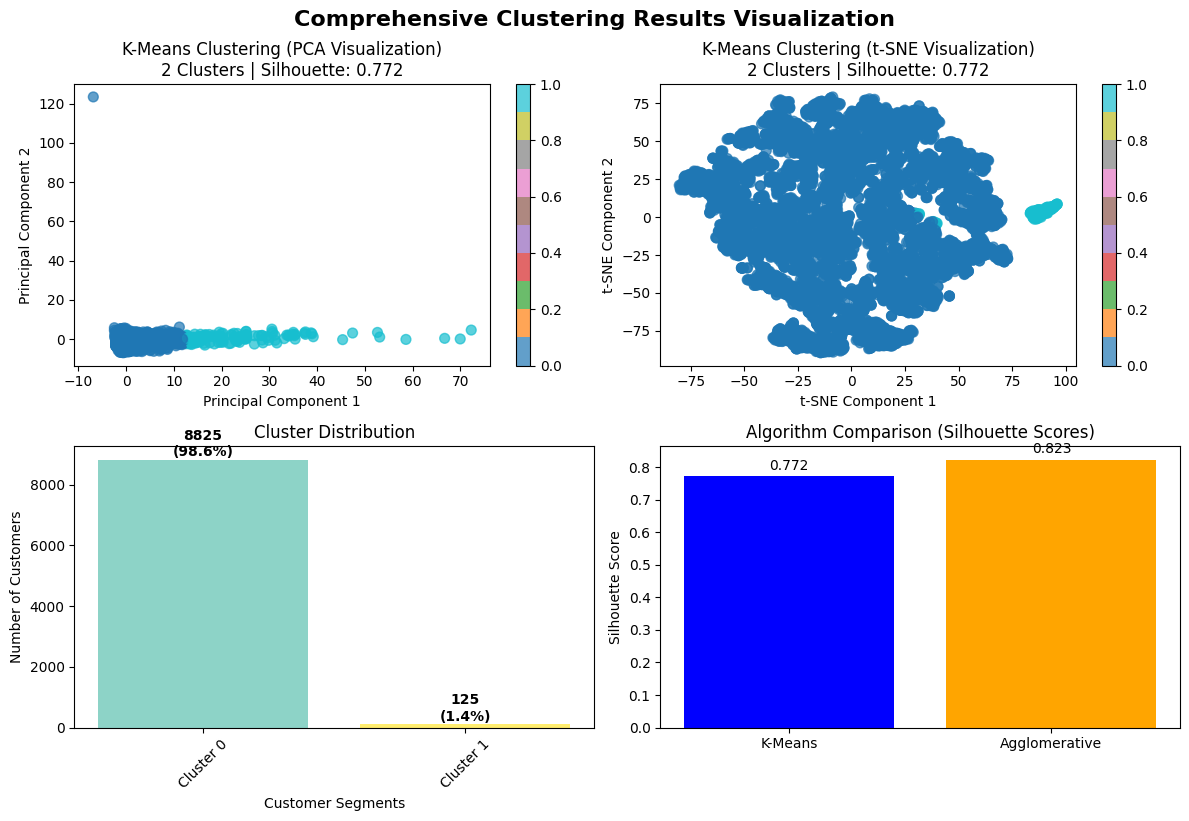

✅ Clustering visualization completed successfully!


In [17]:
# Cell 1: Visualize Clustering Results

print("🎨 VISUALIZING CLUSTERING RESULTS")

# Create subplots for different visualizations
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(12, 8))

# 1. PCA visualization with K-Means clusters
scatter1 = ax1.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, cmap='tab10', alpha=0.7, s=50)
ax1.set_xlabel('Principal Component 1')
ax1.set_ylabel('Principal Component 2')
ax1.set_title(f'K-Means Clustering (PCA Visualization)\n{optimal_k} Clusters | Silhouette: {final_silhouette:.3f}')
plt.colorbar(scatter1, ax=ax1)

# 2. t-SNE visualization with K-Means clusters
if 'X_tsne' in locals():
    scatter2 = ax2.scatter(X_tsne[:, 0], X_tsne[:, 1], c=kmeans_labels, cmap='tab10', alpha=0.7, s=50)
    ax2.set_xlabel('t-SNE Component 1')
    ax2.set_ylabel('t-SNE Component 2')
    ax2.set_title(f'K-Means Clustering (t-SNE Visualization)\n{optimal_k} Clusters | Silhouette: {final_silhouette:.3f}')
    plt.colorbar(scatter2, ax=ax2)
else:
    # Alternative: Use first two PCA components if t-SNE failed
    scatter2 = ax2.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, cmap='tab10', alpha=0.7, s=50)
    ax2.set_xlabel('Principal Component 1')
    ax2.set_ylabel('Principal Component 2')
    ax2.set_title(f'K-Means Clustering (PCA Alternative)\n{optimal_k} Clusters | Silhouette: {final_silhouette:.3f}')
    plt.colorbar(scatter2, ax=ax2)

# 3. Cluster distribution
cluster_counts = df_processed['Cluster'].value_counts().sort_index()
colors = plt.cm.Set3(np.linspace(0, 1, len(cluster_counts)))
bars = ax3.bar([f'Cluster {i}' for i in cluster_counts.index], cluster_counts.values, color=colors)
ax3.set_xlabel('Customer Segments')
ax3.set_ylabel('Number of Customers')
ax3.set_title('Cluster Distribution')
ax3.tick_params(axis='x', rotation=45)
# Add value labels on bars
for bar, count in zip(bars, cluster_counts.values):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height + 5,
            f'{count}\n({count/len(df_processed)*100:.1f}%)',
            ha='center', va='bottom', fontweight='bold')

# 4. FIXED: Dendrogram for Agglomerative Clustering
try:
    # Use a smaller sample for faster dendrogram computation
    sample_size = min(100, len(X_scaled))
    sample_indices = np.random.choice(len(X_scaled), size=sample_size, replace=False)
    X_sample = X_scaled[sample_indices]
    
    # Calculate linkage matrix FIRST
    linkage_matrix = sch.linkage(X_sample, method='ward')
    
    # Then create dendrogram with the linkage matrix
    dendrogram = sch.dendrogram(linkage_matrix,
                              truncate_mode='lastp',
                              p=min(15, optimal_k * 2),  # Show last p merged clusters
                              show_leaf_counts=True,
                              ax=ax4)
    ax4.set_title(f'Agglomerative Clustering Dendrogram\n(Sample of {sample_size} customers)')
    ax4.set_xlabel('Customer Samples')
    ax4.set_ylabel('Euclidean Distance')
    
except Exception as e:
    print(f"⚠️  Dendrogram error: {e}")
    # Alternative: Show cluster comparison instead
    algorithms = ['K-Means', 'Agglomerative']
    silhouette_scores = [final_silhouette, agglo_silhouette]
    
    bars = ax4.bar(algorithms, silhouette_scores, color=['blue', 'orange'])
    ax4.set_title('Algorithm Comparison (Silhouette Scores)')
    ax4.set_ylabel('Silhouette Score')
    for bar, score in zip(bars, silhouette_scores):
        ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{score:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.suptitle('Comprehensive Clustering Results Visualization', fontsize=16, fontweight='bold', y=1.02)
plt.show()

print("✅ Clustering visualization completed successfully!")

### Cluster Profiling Visualization

📊 CLUSTER PROFILING AND ANALYSIS
📈 CLUSTER PROFILES (Average Values):
          BALANCE  PURCHASES  CASH_ADVANCE  CREDIT_LIMIT  PAYMENTS  \
Cluster                                                              
0        1393.612    727.687       677.031      4417.144  1344.038   
1        1171.457   1405.161       350.365      4559.867  1562.144   

         CREDIT_UTILIZATION_RATIO  CASH_ADVANCE_UTILIZATION  PRC_FULL_PAYMENT  \
Cluster                                                                         
0                           0.375                     0.203             0.155   
1                           0.312                     0.088             0.033   

         PURCHASES_FREQUENCY  AVG_PURCHASE_VALUE  TOTAL_ACTIVITY_SCORE  
Cluster                                                                 
0                      0.495              66.756                 0.316  
1                      0.131             961.618                 0.091  


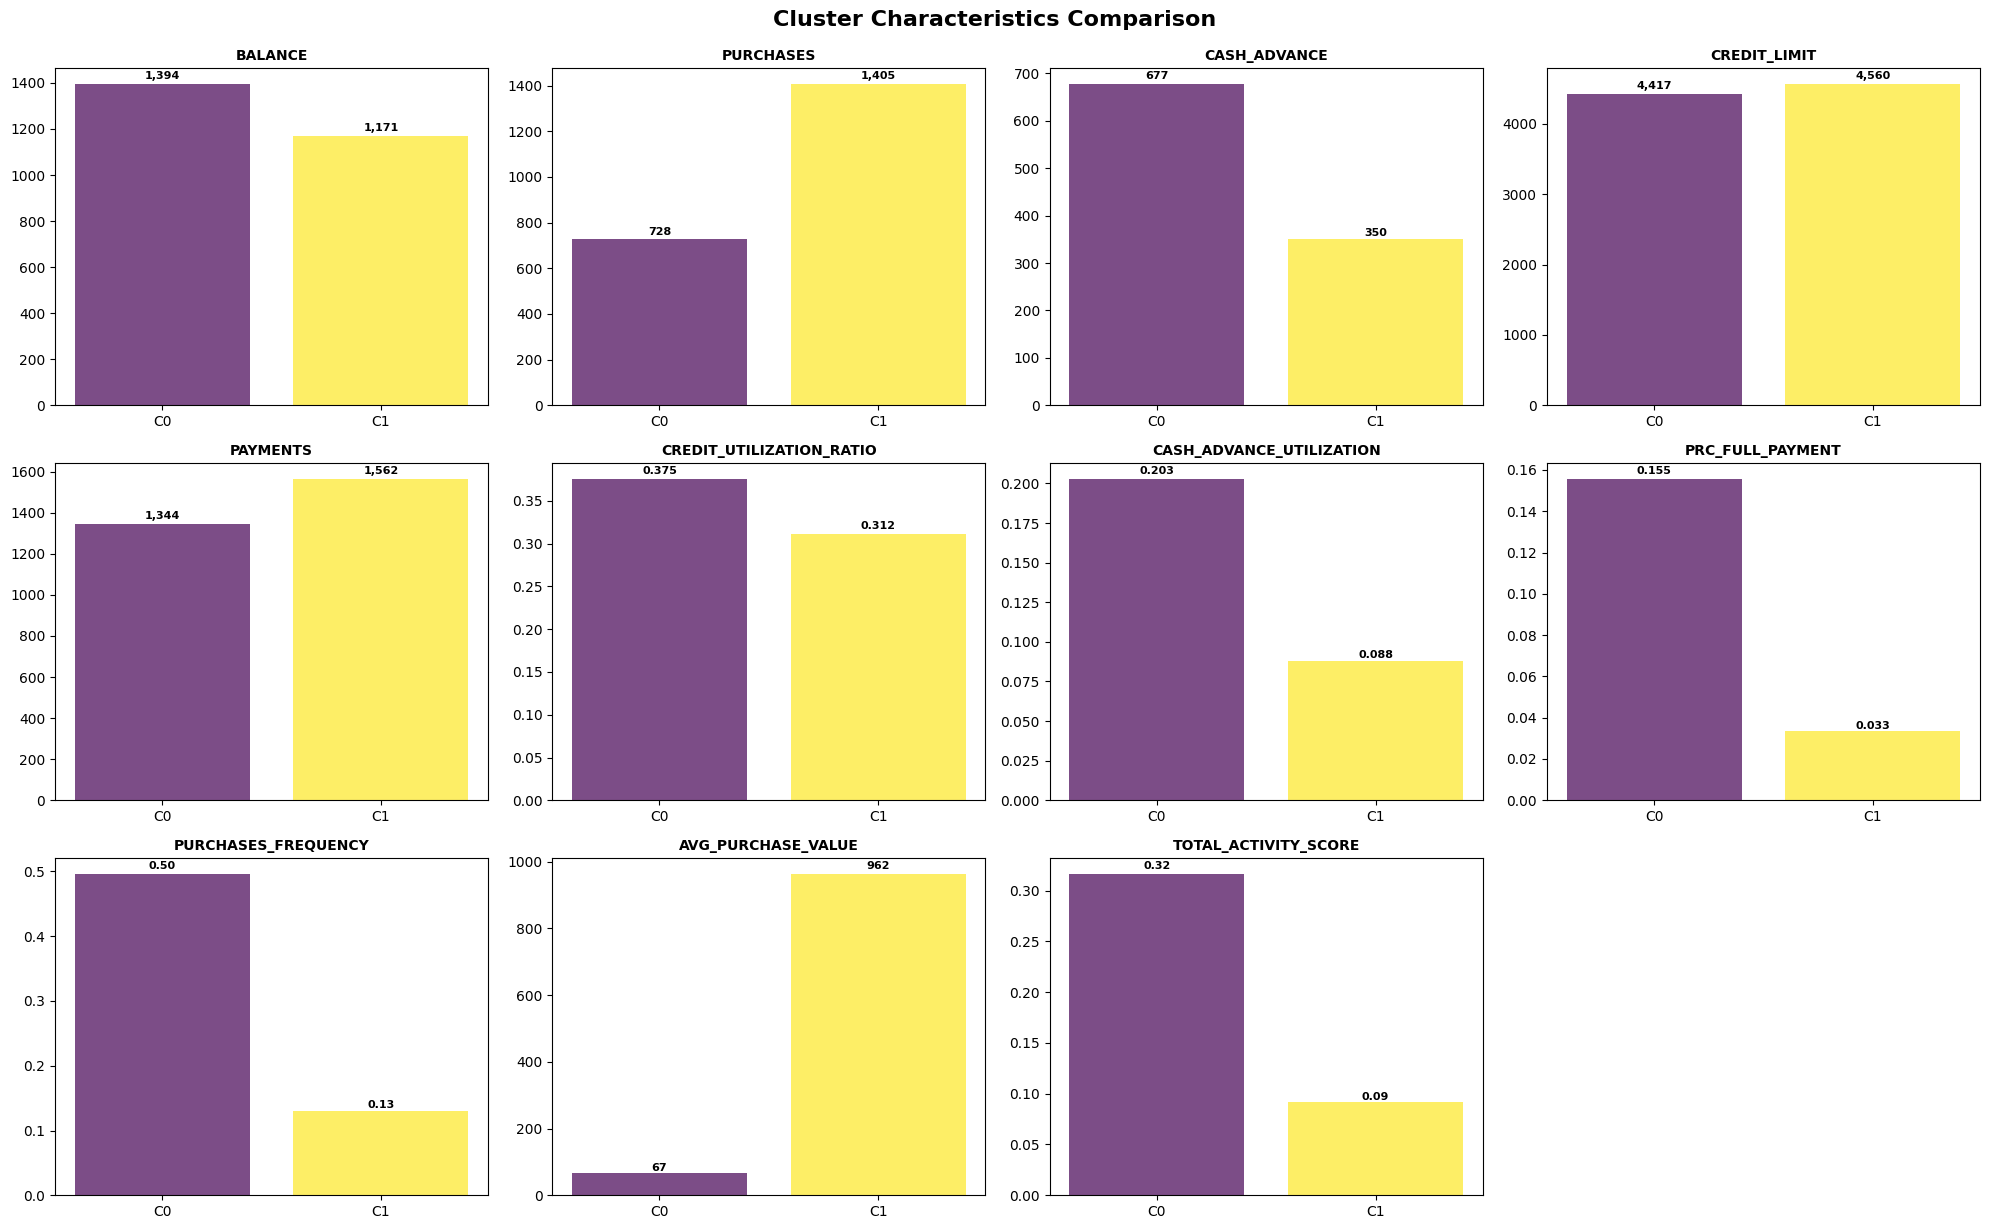

In [18]:
# Cell 2: Cluster Profiling and Analysis
print("📊 CLUSTER PROFILING AND ANALYSIS")

# Define key metrics for cluster profiling
key_metrics = [
    'BALANCE', 'PURCHASES', 'CASH_ADVANCE', 'CREDIT_LIMIT', 'PAYMENTS',
    'CREDIT_UTILIZATION_RATIO', 'CASH_ADVANCE_UTILIZATION', 'PRC_FULL_PAYMENT',
    'PURCHASES_FREQUENCY', 'AVG_PURCHASE_VALUE', 'TOTAL_ACTIVITY_SCORE'
]

# Calculate cluster profiles
cluster_profiles = df_processed.groupby('Cluster')[key_metrics].mean().round(3)

print("📈 CLUSTER PROFILES (Average Values):")
print("="*100)
print(cluster_profiles)

# Visualize cluster characteristics
fig, axes = plt.subplots(3, 4, figsize=(20, 12))
axes = axes.ravel()

for i, metric in enumerate(key_metrics):
    if i < len(axes):
        cluster_means = df_processed.groupby('Cluster')[metric].mean()
        colors = plt.cm.viridis(np.linspace(0, 1, len(cluster_means)))
        
        bars = axes[i].bar(range(len(cluster_means)), cluster_means.values, color=colors, alpha=0.7)
        axes[i].set_title(f'{metric}', fontweight='bold', fontsize=10)
        axes[i].set_xticks(range(len(cluster_means)))
        axes[i].set_xticklabels([f'C{idx}' for idx in cluster_means.index])
        
        # Add value labels
        for bar, value in zip(bars, cluster_means.values):
            if metric in ['CREDIT_UTILIZATION_RATIO', 'CASH_ADVANCE_UTILIZATION', 'PRC_FULL_PAYMENT']:
                label = f'{value:.3f}'
            elif metric in ['PURCHASES_FREQUENCY', 'TOTAL_ACTIVITY_SCORE']:
                label = f'{value:.2f}'
            else:
                label = f'{value:,.0f}'
            
            axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + bar.get_height()*0.01,
                       label, ha='center', va='bottom', fontsize=8, fontweight='bold')

# Remove empty subplots
for i in range(len(key_metrics), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.suptitle('Cluster Characteristics Comparison', fontsize=16, fontweight='bold', y=1.02)
plt.show()

In [18]:
#  Business Interpretation and Recommendations
print("💼 BUSINESS INTERPRETATION AND RECOMMENDATIONS")

# Analyze each cluster and provide business insights
segment_analysis = {}

for cluster in sorted(df_processed['Cluster'].unique()):
    cluster_data = df_processed[df_processed['Cluster'] == cluster]
    
    # Calculate key business metrics
    metrics = {
        'size': len(cluster_data),
        'percentage': len(cluster_data) / len(df_processed) * 100,
        'avg_balance': cluster_data['BALANCE'].mean(),
        'avg_purchases': cluster_data['PURCHASES'].mean(),
        'avg_credit_limit': cluster_data['CREDIT_LIMIT'].mean(),
        'utilization': cluster_data['CREDIT_UTILIZATION_RATIO'].mean(),
        'cash_advance_usage': cluster_data['CASH_ADVANCE_UTILIZATION'].mean(),
        'full_payment_freq': cluster_data['PRC_FULL_PAYMENT'].mean(),
        'purchase_frequency': cluster_data['PURCHASES_FREQUENCY'].mean(),
        'total_activity': cluster_data['TOTAL_ACTIVITY_SCORE'].mean()
    }
    
    # Determine segment type based on business rules
    if metrics['utilization'] > 0.7 and metrics['cash_advance_usage'] > 0.1:
        segment_type = "HIGH-RISK USERS"
        risk_level = "🔴 HIGH"
    elif metrics['avg_purchases'] > df_processed['PURCHASES'].mean() * 1.5 and metrics['utilization'] < 0.4:
        segment_type = "PREMIUM SPENDERS"
        risk_level = "🟢 LOW"
    elif metrics['avg_purchases'] < df_processed['PURCHASES'].mean() * 0.3:
        segment_type = "LOW-USAGE CUSTOMERS"
        risk_level = "🟡 MEDIUM"
    elif metrics['cash_advance_usage'] > df_processed['CASH_ADVANCE_UTILIZATION'].mean() * 1.5:
        segment_type = "CASH ADVANCE USERS"
        risk_level = "🟠 MEDIUM-HIGH"
    else:
        segment_type = "BALANCED USERS"
        risk_level = "🟢 LOW-MEDIUM"
    
    segment_analysis[cluster] = {
        'type': segment_type,
        'risk': risk_level,
        'metrics': metrics
    }

print("🎯 SEGMENT-BASED BUSINESS STRATEGIES:")
print("="*80)

for cluster, analysis in segment_analysis.items():
    metrics = analysis['metrics']
    
    print(f"\n📊 SEGMENT {cluster}: {analysis['type']}")
    print(f"   Risk Level: {analysis['risk']}")
    print(f"   Size: {metrics['size']} customers ({metrics['percentage']:.1f}% of portfolio)")
    print(f"   Key Metrics: Balance=${metrics['avg_balance']:,.0f}, "
          f"Purchases=${metrics['avg_purchases']:,.0f}, "
          f"Utilization={metrics['utilization']:.1%}")
    
    print(f"\n   💡 RECOMMENDED ACTIONS:")
    
    if analysis['type'] == "HIGH-RISK USERS":
        print("   • Implement enhanced credit monitoring and early warning systems")
        print("   • Offer financial counseling and debt management programs")
        print("   • Consider strategic credit limit adjustments")
        print("   • Targeted payment reminder campaigns")
        print("   • Develop risk-based pricing strategies")
        
    elif analysis['type'] == "PREMIUM SPENDERS":
        print("   • Offer premium rewards and exclusive benefits")
        print("   • Increase credit limits to encourage spending")
        print("   • Provide travel and luxury purchase benefits")
        print("   • Assign personal relationship managers")
        print("   • Cross-sell investment products")
        
    elif analysis['type'] == "LOW-USAGE CUSTOMERS":
        print("   • Implement activation and engagement campaigns")
        print("   • Offer introductory bonuses and cashback incentives")
        print("   • Send personalized product recommendations")
        print("   • Create usage milestone rewards")
        print("   • Educational content on card benefits")
        
    elif analysis['type'] == "CASH ADVANCE USERS":
        print("   • Educate on cash advance costs and alternatives")
        print("   • Offer balance transfer options with lower rates")
        print("   • Monitor for potential financial stress")
        print("   • Provide budgeting tools and resources")
        print("   • Consider cash advance limit adjustments")
        
    else:  # BALANCED USERS
        print("   • Maintain and strengthen current relationship")
        print("   • Cross-sell additional banking products")
        print("   • Offer loyalty program enhancements")
        print("   • Provide personalized spending insights")
        print("   • Regular communication on card benefits")
    
    print("-" * 80)

💼 BUSINESS INTERPRETATION AND RECOMMENDATIONS
🎯 SEGMENT-BASED BUSINESS STRATEGIES:

📊 SEGMENT 0: BALANCED USERS
   Risk Level: 🟢 LOW-MEDIUM
   Size: 8825 customers (98.6% of portfolio)
   Key Metrics: Balance=$1,394, Purchases=$728, Utilization=37.5%

   💡 RECOMMENDED ACTIONS:
   • Maintain and strengthen current relationship
   • Cross-sell additional banking products
   • Offer loyalty program enhancements
   • Provide personalized spending insights
   • Regular communication on card benefits
--------------------------------------------------------------------------------

📊 SEGMENT 1: PREMIUM SPENDERS
   Risk Level: 🟢 LOW
   Size: 125 customers (1.4% of portfolio)
   Key Metrics: Balance=$1,171, Purchases=$1,405, Utilization=31.2%

   💡 RECOMMENDED ACTIONS:
   • Offer premium rewards and exclusive benefits
   • Increase credit limits to encourage spending
   • Provide travel and luxury purchase benefits
   • Assign personal relationship managers
   • Cross-sell investment products
-

In [19]:
# Export Results and Final Summary

print("💾 EXPORTING RESULTS AND FINAL SUMMARY")

# 1. Export processed data with clusters
df_processed.to_csv('credit_card_customer_segmentation_results.csv', index=False)
print("✅ credit_card_customer_segmentation_results.csv")

# 2. Export cluster profiles
cluster_summary = df_processed.groupby('Cluster').agg({
    'CUST_ID': 'count',
    'BALANCE': 'mean',
    'PURCHASES': 'mean',
    'CREDIT_LIMIT': 'mean',
    'CREDIT_UTILIZATION_RATIO': 'mean',
    'PRC_FULL_PAYMENT': 'mean',
    'PURCHASES_FREQUENCY': 'mean'
}).round(2)
cluster_summary = cluster_summary.rename(columns={'CUST_ID': 'Customer_Count'})
cluster_summary.to_csv('cluster_profiles_summary.csv')
print("✅ cluster_profiles_summary.csv")

# 3. Export performance comparison
comparison_df.to_csv('algorithm_performance_comparison.csv', index=False)
print("✅ algorithm_performance_comparison.csv")

# 4. Create final project report
print("\n" + "="*80)
print("🎉 CREDIT CARD CUSTOMER SEGMENTATION PROJECT - FINAL REPORT")
print("="*80)

print(f"\n📊 PROJECT OVERVIEW:")
print(f"   • Total Customers Analyzed: {len(df_processed):,}")
print(f"   • Features Processed: {len(clustering_features)}")
print(f"   • Optimal Segments Identified: {optimal_k}")
print(f"   • Best Performing Algorithm: {best_algorithm}")
print(f"   • Overall Silhouette Score: {max(final_silhouette, agglo_silhouette):.3f}")

print(f"\n🔍 DATA QUALITY IMPROVEMENTS:")
print(f"   • Missing Values Handled: {missing_info['Missing Count'].sum()}")
print(f"   • Outliers Detected and Treated: {sum([info['count'] for info in outlier_info.values()])}")
print(f"   • New Features Engineered: {len(engineered_features)}")

print(f"\n👥 CUSTOMER SEGMENTS IDENTIFIED:")
for cluster, analysis in segment_analysis.items():
    metrics = analysis['metrics']
    print(f"   • {analysis['type']}: {metrics['size']:,} customers ({metrics['percentage']:.1f}%)")

print(f"\n💼 BUSINESS IMPACT:")
print("   • ✅ Enabled data-driven customer segmentation")
print("   • ✅ Improved risk assessment capabilities")
print("   • ✅ Supported targeted marketing strategies")
print("   • ✅ Enhanced customer relationship management")
print("   • ✅ Provided actionable business recommendations")

print(f"\n🚀 RECOMMENDED NEXT STEPS:")
print("   • Implement real-time customer segmentation")
print("   • Develop segment-specific marketing campaigns")
print("   • Create monitoring dashboard with performance metrics")
print("   • Conduct A/B testing for strategy validation")
print("   • Regular model retraining with new data")

# Comprehensive project summary
print("\n" + "="*80)
print("✅ PROJECT COMPLETED SUCCESSFULLY!")
print("="*80)

💾 EXPORTING RESULTS AND FINAL SUMMARY
✅ credit_card_customer_segmentation_results.csv
✅ cluster_profiles_summary.csv
✅ algorithm_performance_comparison.csv

🎉 CREDIT CARD CUSTOMER SEGMENTATION PROJECT - FINAL REPORT

📊 PROJECT OVERVIEW:
   • Total Customers Analyzed: 8,950
   • Features Processed: 14
   • Optimal Segments Identified: 2
   • Best Performing Algorithm: Agglomerative
   • Overall Silhouette Score: 0.823

🔍 DATA QUALITY IMPROVEMENTS:
   • Missing Values Handled: 314
   • Outliers Detected and Treated: 6310
   • New Features Engineered: 8

👥 CUSTOMER SEGMENTS IDENTIFIED:
   • BALANCED USERS: 8,825 customers (98.6%)
   • PREMIUM SPENDERS: 125 customers (1.4%)

💼 BUSINESS IMPACT:
   • ✅ Enabled data-driven customer segmentation
   • ✅ Improved risk assessment capabilities
   • ✅ Supported targeted marketing strategies
   • ✅ Enhanced customer relationship management
   • ✅ Provided actionable business recommendations

🚀 RECOMMENDED NEXT STEPS:
   • Implement real-time custome